In [5]:
import cv2
import pytesseract
from matplotlib import pyplot as plt

print("đã import hàm helper.py")
pytesseract.pytesseract.tesseract_cmd = "/opt/homebrew/bin/tesseract"

CORRECT_MAP = {'O':'0','I':'1','L':'1','T':'1','Z':'2','S':'5','B':'8','A':'4'}
LETTER_TO_NUMBER = {'O':'0','I':'1','L':'1','T':'1','S':'5','B':'8','Z':'2','A':'4'}
NUMBER_TO_LETTER = {'0':'O','1':'I','2':'Z','5':'S','8':'B','4':'A'}


def ocr_image(img, whitelist="ABCDEFGHJKLMNPSTUVXYZ0123456789"):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    config = f"--psm 7 -c tessedit_char_whitelist={whitelist}"
    return pytesseract.image_to_string(thresh, config=config).strip().replace(" ", "")


def correct_plate_text(text):
    corrected = "".join([CORRECT_MAP.get(ch, ch) for ch in text.upper()])
    return corrected


def process_horizontal_plate(text):
    text = text.upper()
    chars = list(text)
    if len(chars) == 9:
        if chars[0] not in '234567890':
            chars = chars[1:]
        elif chars[-1] not in '234567890':
            chars = chars[:-1]
    elif len(chars) == 10:
        chars = chars[1:-1]
    if len(chars) >= 3 and chars[2].isdigit():
        chars[2] = NUMBER_TO_LETTER.get(chars[2], chars[2])
    for i, ch in enumerate(chars):
        if i != 2 and ch.isalpha():
            chars[i] = LETTER_TO_NUMBER.get(ch, '0')
    return "".join(chars)


def correct_plate_text_by_position(text, top_len):
    text = text.upper()
    top = list(text[:top_len])
    bottom = list(text[top_len:])
    if len(top) == 5:
        if top[0] not in '234567890': top = top[1:]
        elif top[-1] not in '234567890': top = top[:-1]
    elif len(top) == 6:
        top = top[1:-1]
    if len(bottom) == 6:
        if bottom[0] not in '234567890': bottom = bottom[1:]
        elif bottom[-1] not in '234567890': bottom = bottom[:-1]
    elif len(bottom) == 7:
        bottom = bottom[1:-1]
    for i, ch in enumerate(top):
        if i == 2 and ch.isdigit(): top[i] = NUMBER_TO_LETTER.get(ch, ch)
        elif i != 2 and ch.isalpha(): top[i] = LETTER_TO_NUMBER.get(ch, '0')
    bottom = [LETTER_TO_NUMBER.get(ch, ch) for ch in bottom]
    return "".join(top + bottom)

crop_img="./top_plate.jpg"
def read_plate_from_crop(crop_img, is_two_lines=False, show_crop=False):
    if show_crop:
        # Chuyển BGR sang RGB để hiển thị đúng màu trong matplotlib
        rgb_crop = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6,2))
        plt.imshow(rgb_crop)
        plt.axis('off')
        plt.show()
        
    if is_two_lines:
        h = crop_img.shape[0] // 2
        top_img = crop_img[:h, :]
        bottom_img = crop_img[h:, :]
        top_text = ocr_image(top_img)
        bottom_text = ocr_image(bottom_img)
        return correct_plate_text_by_position(top_text + bottom_text, top_len=len(top_text))
    else:
        text = ocr_image(crop_img)
        return process_horizontal_plate(text)


đã import hàm helper.py


In [2]:
import pandas as pd

# Giả lập danh sách ảnh (sau này bạn thay bằng đường dẫn thật)
image_paths = [
 "./crop.jpg"
]

# Giả lập kết quả OCR
plates_detected = [
    "29A12345",
    
]

# Giả lập vị trí bbox (xmin, ymin, xmax, ymax)
bbox_list = [
    [100, 50, 300, 120],
    
]

# Tạo DataFrame
df = pd.DataFrame({
    "image_path": image_paths,
    "plate_text": plates_detected,
    "bbox": bbox_list
})

df


,image_path,plate_text,bbox
0,./crop.jpg,29A12345,"[100, 50, 300, 120]"


In [15]:
import cv2

# Giả lập crop_img từ YOLO
crop_img = cv2.imread("./crop.jpg")  # ảnh crop biển số 2 dòng

def read_plate_from_crop(crop_img, save_crops=True):
    h = crop_img.shape[0]
    
    # Cắt top 60% từ đầu
    top_h = int(h * 0.6)
    top_img = crop_img[:top_h, :]
    
    # Cắt bottom 50% từ cuối ảnh
    bottom_h = int(h * 0.5)
    bottom_img = crop_img[-bottom_h:, :]
    
    # Lưu ảnh nếu cần
    if save_crops:
        cv2.imwrite("top_plate.jpg", top_img)
        cv2.imwrite("bottom_plate.jpg", bottom_img)
if crop_img is not None:
    read_plate_from_crop(crop_img, save_crops=True)
else:
    print("Không thể đọc được ảnh './crop.jpg'. Vui lòng kiểm tra đường dẫn và file.")  
   




In [22]:
import cv2
import pytesseract

def ocr_image(img_path, whitelist="-ABCDEFGHJKLMNPSTUVXYZ0123456789"):
    """
    OCR từ file ảnh.
    - img_path: đường dẫn ảnh
    """
    # Load ảnh từ file
    img = cv2.imread(img_path)
    if img is None:
        print(f"Không thể đọc ảnh: {img_path}")
        return ""
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    config = f"--psm 7 -c tessedit_char_whitelist={whitelist}"
    return pytesseract.image_to_string(thresh, config=config).strip().replace(" ", "")

# Ví dụ sử dụng
crop_img_path = "./bottom_plate.jpg"
text = ocr_image(crop_img_path)
print("OCR Result:", text)


OCR Result: 11708


Progress: |██████████████████████████████████████████████████| 100.0% Complete----- Kết quả OCR -----
Văn bản: '81-XI' - Độ tin cậy: 0.9541


/Users/hoangtranminh/Documents/python/model_dectect/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


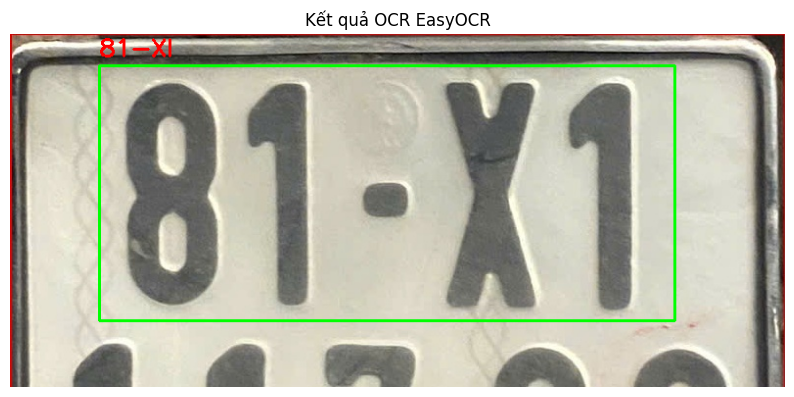

In [ ]:
import easyocr
import cv2
import matplotlib.pyplot as plt

# 1. Khởi tạo Reader (Chọn ngôn ngữ 'vi' cho tiếng Việt và 'en' cho tiếng Anh)
# Lần chạy đầu tiên sẽ tự động tải các model ngôn ngữ cần thiết.
reader = easyocr.Reader(['vi', 'en'])

# 2. Đường dẫn đến ảnh của bạn
# THAY THẾ 'path/to/your/image.jpg' bằng đường dẫn thật của ảnh có chữ viết
image_path = './top_plate.jpg' 

# 3. Thực hiện OCR
# 'result' là một danh sách chứa các box bounding, văn bản và độ tin cậy.
result = reader.readtext(image_path)

# 4. Hiển thị và Phân tích kết quả
print("----- Kết quả OCR -----")


# (TÙY CHỌN) Vẽ kết quả lên ảnh để kiểm tra trực quan
img = cv2.imread(image_path)
if img is not None:
    for (bbox, text, conf) in result:
        # Chuyển đổi tọa độ từ mảng numpy sang tuple
        (top_left, top_right, bottom_right, bottom_left) = bbox
        top_left = tuple(map(int, top_left))
        bottom_right = tuple(map(int, bottom_right))
        
        # Vẽ box bounding (màu xanh lá cây)
        cv2.rectangle(img, top_left, bottom_right, (0, 255, 0), 2)
        
        # Đặt văn bản lên trên box (màu đỏ)
        cv2.putText(img, text, (top_left[0], top_left[1] - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    
    # Hiển thị ảnh (dùng matplotlib hoặc cv2.imshow)
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Kết quả OCR EasyOCR")
    plt.axis('off')
    plt.show()
else:
    print("Lỗi: Không thể đọc được ảnh. Vui lòng kiểm tra đường dẫn.")

In [5]:
# Xử lý bottom bằng vòng lặp for
bottom=['1','2','3','4','5','5']
mapped_bottom = []
for i, ch in enumerate(bottom):
    # Xóa ký tự đầu nếu là chữ
    ch = str(ch)
    if i == 0 and ch.isalpha():
        continue
    # Xóa ký tự cuối nếu là chữ
    if i == len(bottom)-1 and ch.isalpha():
        continue
    mapped_bottom.append(LETTER_TO_NUMBER.get(ch, ch))

# Giả sử mapped_bottom là danh sách ký tự
new_bottom = []
for i, ch in enumerate(mapped_bottom):
    new_bottom.append(ch)
    # Chèn '.' sau ký tự thứ 4 (index 3)
    if i == 3 and len(mapped_bottom) >= 5:
        new_bottom.append('.')


print(new_bottom)

NameError: name 'LETTER_TO_NUMBER' is not defined

In [2]:
bottom = [5435345]  # hoặc bất kỳ số nào
mapped_bottom = []

# Tách từng ký tự
for num in bottom:
    for i, ch in enumerate(str(num)):
        # Xóa ký tự đầu nếu là chữ
        if i == 0 and ch.isalpha():
            continue
        # Xóa ký tự cuối nếu là chữ
        if i == len(str(num))-1 and ch.isalpha():
            continue
        mapped_bottom.append(ch)

# Chèn dấu '.' sau ký tự thứ 4 (index 3) nếu đủ dài
new_bottom = []
for i, ch in enumerate(mapped_bottom):
    new_bottom.append(ch)
    if i == 3 and len(mapped_bottom) >= 5:
        new_bottom.append('.')

print(new_bottom)


['5', '4', '3', '5', '.', '3', '4', '5']
